### Sections
| | |
|---|---|
| **A** | Setup — install, imports, Colab-safe paths |
| **B** | Load artefacts from Notebook 3A |
| **C** | Initialise ChromaDB & index all embeddings |
| **D** | Verify index integrity |
| **E** | Semantic search function |
| **F** | Run 5 business queries end-to-end |
| **G** | Phase 2 complete — artifact checklist |

### A1 — Install Dependencies

In [52]:
# ── A1: Install required libraries ───────────────────────────────────────────
# chromadb              : vector database (in-memory HNSW index)
# sentence-transformers : needed only to embed new queries at search time
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q chromadb sentence-transformers torch
#!pip install -q matplotlib seaborn pandas numpy tqdm

### A2 — Imports

In [53]:
# ── Imports ───────────────────────────────────────────────────────────────
import os, sys, json, warnings
from pathlib import Path
from typing  import List, Dict, Optional

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Sentence Transformers (query embedding at search time)
from sentence_transformers import SentenceTransformer
import torch

# ChromaDB
import chromadb

warnings.filterwarnings("ignore")

root = Path.cwd().parent
sys.path.insert(0, str(root))
from config import DATA_DIR


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Imports successful.")
print(f"Device : {DEVICE}")

Imports successful.
Device : cpu


In [54]:
# ──  Path configuration  ─────────────────────

DATA_DIR_PRO = DATA_DIR / "processed"
MODEL_DIR    = DATA_DIR / "models"
OUTPUT_DIR   = DATA_DIR / "outputs"

# ── Artefact paths produced by 3A ─────────────────────────────────────────────
FINE_TUNED_MODEL = str(MODEL_DIR / "fine_tuned_embedder")
FT_EMBEDDINGS    = OUTPUT_DIR / "ft_embeddings.npy"
CHUNK_METADATA   = OUTPUT_DIR / "chunk_metadata.json"

COLLECTION_NAME  = "supply_chain_kg"

print(f"   Fine-tuned model: {FINE_TUNED_MODEL}")
print(f"   Embeddings file : {FT_EMBEDDINGS}")
print(f"   Metadata file   : {CHUNK_METADATA}")


   Fine-tuned model: /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder
   Embeddings file : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs/ft_embeddings.npy
   Metadata file   : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/outputs/chunk_metadata.json


### Section B — Load Artefacts from Notebook 02-01

In [55]:
# ── Load fine-tuned sentence-transformer Model ──────────────────────────────────
# This model is used ONLY for embedding new user queries at search time.
# The corpus embeddings (ft_embeddings.npy) were pre-computed in 02_01.
# ─────────────────────────────────────────────────────────────────────────────

ft_model_path = Path(FINE_TUNED_MODEL)
if not ft_model_path.exists():
    raise FileNotFoundError(
        f"Fine-tuned model not found: {FINE_TUNED_MODEL}\n"
        "Please run Notebook 3A first."
    )

ft_model = SentenceTransformer(FINE_TUNED_MODEL, device=DEVICE)
print("Fine-tuned model loaded.")
print(f" Path          : {FINE_TUNED_MODEL}")
print(f" Embedding dim : {ft_model.get_sentence_embedding_dimension()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11750.03it/s]

Fine-tuned model loaded.
 Path          : /Users/maheshdhiman/GenerativeAI/supply-chain-optimization-kg/supply-chain-optimization-kg/data/models/fine_tuned_embedder
 Embedding dim : 384


In [56]:
# ── Load pre-computed embeddings and chunk metadata ───────────────────────
# ft_embeddings  : numpy array (n_chunks × 384), L2-normalised float32
# metadata_list  : list of dicts with keys: chunk, entity_type, char_length
# ─────────────────────────────────────────────────────────────────────────────

# -- Embeddings --
if not FT_EMBEDDINGS.exists():
    raise FileNotFoundError(
        f"Embeddings file not found: {FT_EMBEDDINGS}\n"
        "Please run Notebook 3A first."
    )
ft_embeddings = np.load(FT_EMBEDDINGS)
print(f"Embeddings loaded.")
print(f" Shape : {ft_embeddings.shape}")
print(f" Dtype : {ft_embeddings.dtype}")
print(f" Norm  : {np.linalg.norm(ft_embeddings[0]):.4f}  (should be ~1.0)")

# -- Metadata --
if not CHUNK_METADATA.exists():
    raise FileNotFoundError(
        f"Metadata file not found: {CHUNK_METADATA}\n"
        "Please run Notebook 3A first."
    )
with open(CHUNK_METADATA, "r", encoding="utf-8") as f:
    metadata_list: List[Dict] = json.load(f)

# Unpack for convenience
chunks       = [m["chunk"]       for m in metadata_list]
chunk_labels = [m["entity_type"] for m in metadata_list]

print(f"\nChunk metadata loaded.")
print(f" Total chunks : {len(chunks)}")

# Sanity check: lengths must match
assert len(chunks) == ft_embeddings.shape[0], (
    f"Mismatch: {len(chunks)} chunks but {ft_embeddings.shape[0]} embeddings. "
    "Re-run Notebook 3A."
)
print("   Length check : chunks == embeddings rows")

Embeddings loaded.
 Shape : (1410, 384)
 Dtype : float32
 Norm  : 1.0000  (should be ~1.0)

Chunk metadata loaded.
 Total chunks : 1410
   Length check : chunks == embeddings rows


In [57]:
# ── Show corpus distribution so we know what is indexed ───────────
ENTITY_COLORS: Dict[str, str] = {
    "Supplier"       : "#4A90D9",
    "Product"        : "#7ED321",
    "Warehouse"      : "#F5A623",
    "Route"          : "#9B59B6",
    "Order"          : "#1ABC9C",
    "Shipment"       : "#3498DB",
    "Inventory"      : "#E67E22",
    "Customer"       : "#E74C3C",
    "LogisticsEvent" : "#C0392B",
    "Other"          : "#95A5A6",
}

dist = pd.Series(chunk_labels).value_counts().reset_index()
dist.columns = ["entity_type", "count"]
dist["pct"]  = (dist["count"] / len(chunks) * 100).round(1)

print("Corpus ready to index:")
print(dist.to_string(index=False))

Corpus ready to index:
   entity_type  count  pct
         Other    584 41.4
     Warehouse    206 14.6
         Order    151 10.7
      Shipment    119  8.4
       Product    108  7.7
         Route     66  4.7
      Customer     65  4.6
     Inventory     40  2.8
      Supplier     36  2.6
LogisticsEvent     35  2.5


### Section C — Initialise ChromaDB & Index Embeddings
ChromaDB stores each chunk as a **document** with its pre-computed embedding and metadata. Retrieval uses an HNSW approximate nearest-neighbour index with cosine distance.

In [58]:
# ── Create ChromaDB Client & Collection ──────────────────────────────────
# Initialise ChromaDB in-memory client 
# EphemeralClient  : purely in-memory, resets when the session ends.
# hnsw:space=cosine: tells ChromaDB to use cosine distance for HNSW indexing.
#                    distance = 1 - cosine_similarity  (lower = more similar)
# ─────────────────────────────────────────────────────────────────────────────

# Handle API differences between chromadb package versions
try:
    chroma_client = chromadb.EphemeralClient()         # chromadb >= 0.4.x
except AttributeError:
    chroma_client = chromadb.Client()                  # chromadb <  0.4.x

# Delete collection if it already exists (makes cell safely re-runnable)
existing_names = [c.name for c in chroma_client.list_collections()]
if COLLECTION_NAME in existing_names:
    chroma_client.delete_collection(COLLECTION_NAME)
    print(f"   ♻️  Deleted existing collection '{COLLECTION_NAME}'")

collection = chroma_client.create_collection(
    name     = COLLECTION_NAME,
    metadata = {"hnsw:space": "cosine"},
)

print(f"ChromaDB collection created.")
print(f" Name            : {COLLECTION_NAME}")
print(f" Distance metric : cosine")
print(f" Documents       : {collection.count()}  (empty, about to index)")

   ♻️  Deleted existing collection 'supply_chain_kg'
ChromaDB collection created.
 Name            : supply_chain_kg
 Distance metric : cosine
 Documents       : 0  (empty, about to index)


In [59]:
# ── Build IDs & Metadata Records ────────────────────
#   Prepare document IDs and per-chunk metadata dicts
#   ChromaDB requires:
#   ids        : unique string identifier per document (mandatory)
#   documents  : raw text (stored alongside the vector for retrieval)
#   embeddings : pre-computed float list — 384 values per chunk
#   metadatas  : list of flat dicts (string/int/float values only)
# ─────────────────────────────────────────────────────────────────────────────
doc_ids   = [f"chunk_{i:04d}" for i in range(len(chunks))]
metadatas = [
    {
        "entity_type" : metadata_list[i]["entity_type"],
        "char_length" : metadata_list[i]["char_length"],
        "chunk_index" : i,
    }
    for i in range(len(chunks))
]

print(f"IDs and metadata prepared.")
print(f" Total records : {len(doc_ids)}")
print(f" Sample ID     : {doc_ids[0]}  ...  {doc_ids[-1]}")
print(f" Sample meta   : {metadatas[0]}")

IDs and metadata prepared.
 Total records : 1410
 Sample ID     : chunk_0000  ...  chunk_1409
 Sample meta   : {'entity_type': 'Other', 'char_length': 24, 'chunk_index': 0}


In [60]:
# ── CIndex in Batches : Add all documents to ChromaDB in batches ─────────────
# Batching avoids hitting ChromaDB's internal size limits and keeps memory
# usage predictable on Colab's free tier.
# ─────────────────────────────────────────────────────────────────────────────

BATCH_SIZE    = 200
total_indexed = 0

print(f"Indexing {len(chunks)} chunks into ChromaDB ...")
for start in tqdm(range(0, len(chunks), BATCH_SIZE), desc="Indexing batches"):
    end = min(start + BATCH_SIZE, len(chunks))

    collection.add(
        ids        = doc_ids[start:end],
        documents  = chunks[start:end],
        embeddings = ft_embeddings[start:end].tolist(),  # numpy → Python list
        metadatas  = metadatas[start:end],
    )
    total_indexed += (end - start)

final_count = collection.count()
print(f"\nIndexing complete.")
print(f" Documents indexed : {total_indexed}")
print(f" Collection count  : {final_count}")
assert final_count == len(chunks), (
    f"Index count mismatch: expected {len(chunks)}, got {final_count}"
)
print(" Count assertion   : passed")


Indexing 1410 chunks into ChromaDB ...


Indexing batches: 100%|██████████| 8/8 [00:00<00:00, 24.69it/s]


Indexing complete.
 Documents indexed : 1410
 Collection count  : 1410
 Count assertion   : passed


### Section D 
### Verify Index Integrity : Spot-Check by ID

In [61]:
# ── Retrieve a known document and confirm it matches the source chunk ─────

TEST_IDX = 42
test_id  = doc_ids[TEST_IDX]

result = collection.get(
    ids     = [test_id],
    include = ["documents", "metadatas"],
)

retrieved_doc  = result["documents"][0]
retrieved_meta = result["metadatas"][0]
original_doc   = chunks[TEST_IDX]

print("Spot-check by ID:")
print(f" ID queried       : {test_id}")
print(f" Original chunk   : {original_doc[:80]}...")
print(f" Retrieved chunk  : {retrieved_doc[:80]}...")
print(f" Text match       : {retrieved_doc == original_doc}")
print(f" Metadata         : {retrieved_meta}")


Spot-check by ID:
 ID queried       : chunk_0042
 Original chunk   : 9 has region value South....
 Retrieved chunk  : 9 has region value South....
 Text match       : True
 Metadata         : {'entity_type': 'Other', 'char_length': 25, 'chunk_index': 42}


In [62]:

# ────── Per-Type Count Verification ────────
# Count indexed documents per entity type via metadata filter 
print("Per-entity-type index counts:")
count_rows = []
for etype in ["Supplier","Product","Warehouse","Route","Order",
              "Shipment","Inventory","Customer","LogisticsEvent"]:
    result = collection.get(where={"entity_type": etype}, include=[])
    indexed = len(result["ids"])
    expected = chunk_labels.count(etype)
    match    = "Y" if indexed == expected else "N"
    count_rows.append({
        "Entity Type" : etype,
        "Indexed"     : indexed,
        "In Corpus"   : expected,
        "Match"       : match,
    })

    print(f"   {etype:<18}: indexed={indexed:>4}  corpus={expected:>4}  {match}")

df_counts = pd.DataFrame(count_rows)

Per-entity-type index counts:
   Supplier          : indexed=  36  corpus=  36  Y
   Product           : indexed= 108  corpus= 108  Y
   Warehouse         : indexed= 206  corpus= 206  Y
   Route             : indexed=  66  corpus=  66  Y
   Order             : indexed= 151  corpus= 151  Y
   Shipment          : indexed= 119  corpus= 119  Y
   Inventory         : indexed=  40  corpus=  40  Y
   Customer          : indexed=  65  corpus=  65  Y
   LogisticsEvent    : indexed=  35  corpus=  35  Y


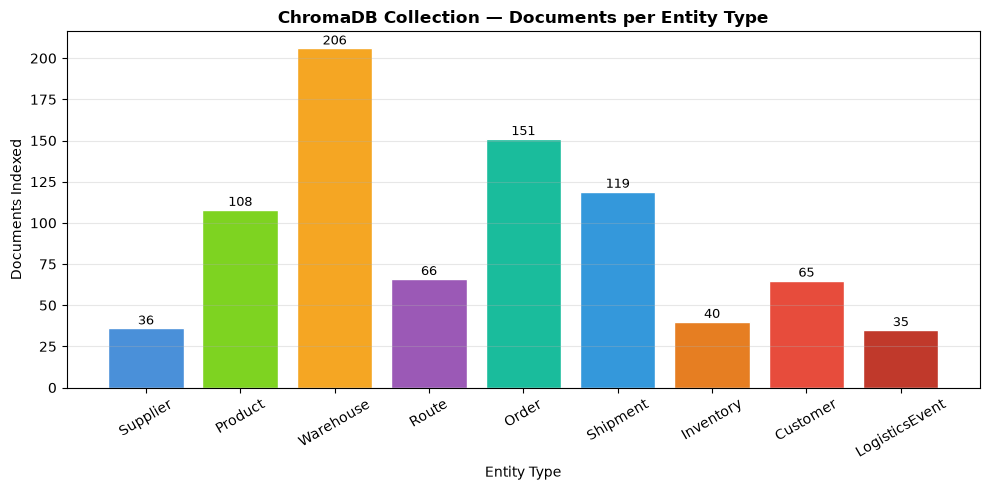

Index distribution chart saved → outputs/3b_index_distribution.png


In [63]:
# ── Visualise Index DistributionBar chart of indexed documents by entity type ────────────────

fig, ax = plt.subplots(figsize=(10, 5))
colors  = [ENTITY_COLORS.get(e, "#95A5A6") for e in df_counts["Entity Type"]]
bars    = ax.bar(df_counts["Entity Type"], df_counts["Indexed"],
                 color=colors, edgecolor="white")

for bar, cnt in zip(bars, df_counts["Indexed"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(cnt), ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Entity Type")
ax.set_ylabel("Documents Indexed")
ax.set_title("ChromaDB Collection — Documents per Entity Type", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "3b_index_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Index distribution chart saved → outputs/3b_index_distribution.png")

### Section E — Semantic Search Function
The pipeline: **query text → fine-tuned embedding → ChromaDB HNSW search → ranked results with scores**.

In [64]:
# ──── Define the semantic search function ────────────────────────────────────
# This function is the core retrieval engine.
# In RAG phase, it will be called by the LangChain retriever to
# fetch context chunks before passing them to the Groq LLM.
# ─────────────────────────────────────────────────────────────────────────────

def semantic_search(
    query          : str,
    n_results      : int = 5,
    filter_type    : Optional[str] = None,
    verbose        : bool = True,
) -> pd.DataFrame:
    """
    Retrieve the top-n most semantically similar KG chunks for a query.

    Parameters
    ----------
    query       : Natural language question from the user / business analyst.
    n_results   : Number of results to return (default 5).
    filter_type : Optional ChromaDB where-filter to restrict to one entity
                  type e.g. 'Supplier'. Pass None to search the full corpus.
    verbose     : Print formatted results to stdout.

    Returns
    -------
    pd.DataFrame with columns:
        rank, similarity, entity_type, char_length, chunk
    """
    # Step 1 — embed the query using the same model used for corpus indexing
    q_embedding: List[float] = ft_model.encode(
        [query],
        convert_to_numpy     = True,
        normalize_embeddings = True,   # must match indexing normalisation
    ).tolist()

    # Step 2 — build optional metadata filter
    where: Optional[Dict] = {"entity_type": filter_type} if filter_type else None

    # Step 3 — query ChromaDB
    # ChromaDB returns distances (cosine distance = 1 - cosine_similarity)
    # so similarity = 1 - distance
    results = collection.query(
        query_embeddings = q_embedding,
        n_results        = n_results,
        where            = where,
        include          = ["documents", "distances", "metadatas"],
    )

    docs      = results["documents"][0]
    distances = results["distances"][0]
    metas     = results["metadatas"][0]

    # Step 4 — assemble result dataframe
    rows = []
    for rank, (doc, dist, meta) in enumerate(zip(docs, distances, metas), start=1):
        rows.append({
            "rank"        : rank,
            "similarity"  : round(1.0 - dist, 4),
            "entity_type" : meta.get("entity_type", "Unknown"),
            "char_length" : meta.get("char_length", 0),
            "chunk"       : doc,
        })
    df = pd.DataFrame(rows)

    # Step 5 — optional console output
    if verbose:
        filter_note = f"  [filter: entity_type='{filter_type}']" if filter_type else ""
        print(f"\n🔍 Query: \"{query}\"{filter_note}")
        print(f"{'─'*68}")
        for _, row in df.iterrows():
            print(f" #{row['rank']}  [{row['entity_type']:<16}]  sim={row['similarity']:.4f}")
            print(f"     {row['chunk'][:85]}...")

    return df

print("semantic_search() function defined.")
print(" Usage: df = semantic_search('your query here', n_results=5)")

semantic_search() function defined.
 Usage: df = semantic_search('your query here', n_results=5)


### Section F — 5 Business Queries End-to-End
The retrieved chunks become the **RAG context** fed to the Groq LLM in Phase 3.

In [65]:
# ────────────────── Define the 5 key business queries ────────────────────
BUSINESS_QUERIES: List[Dict] = [
    {
        "id"          : "BQ-01",
        "query"       : "Which suppliers have a lead time over 20 days and low reliability?",
        "business_use": "Supplier risk assessment",
        "filter_type" : None,               # search full corpus
    },
    {
        "id"          : "BQ-02",
        "query"       : "What routes are causing delivery delays in the supply chain?",
        "business_use": "Logistics bottleneck identification",
        "filter_type" : None,
    },
    {
        "id"          : "BQ-03",
        "query"       : "Which warehouses are near full capacity and need load redistribution?",
        "business_use": "Warehouse capacity management",
        "filter_type" : "Warehouse",        # restrict to warehouse chunks only
    },
    {
        "id"          : "BQ-04",
        "query"       : "Which products are critically low on stock and need urgent reordering?",
        "business_use": "Inventory replenishment decision",
        "filter_type" : None,
    },
    {
        "id"          : "BQ-05",
        "query"       : "What logistics events caused the most significant supply chain disruptions?",
        "business_use": "Supply chain disruption analysis",
        "filter_type" : None,
    },
]


In [66]:
# ── Execute Queries: Run all 5 business queries through the semantic search pipeline ────────

all_results: Dict[str, pd.DataFrame] = {}

print("=" * 68)
print("  SEMANTIC SEARCH — BUSINESS QUERY RESULTS")
print("=" * 68)

for bq in BUSINESS_QUERIES:
    print(f"\n{'━'*68}")
    print(f"  {bq['id']} | {bq['business_use']}")
    print(f"{'━'*68}")

    df_res = semantic_search(
        query       = bq["query"],
        n_results   = 5,
        filter_type = bq["filter_type"],
        verbose     = True,
    )
    all_results[bq["id"]] = df_res

print(f"\n{'='*68}")

  SEMANTIC SEARCH — BUSINESS QUERY RESULTS

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BQ-01 | Supplier risk assessment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 Query: "Which suppliers have a lead time over 20 days and low reliability?"
────────────────────────────────────────────────────────────────────
 #1  [Supplier        ]  sim=0.4651
     14 has supplier 5....
 #2  [Supplier        ]  sim=0.4415
     18 has supplier 5....
 #3  [Supplier        ]  sim=0.4350
     14 has supplier 6....
 #4  [Supplier        ]  sim=0.4268
     20 has supplier 4....
 #5  [Supplier        ]  sim=0.4247
     8 has supplier 5....

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BQ-02 | Logistics bottleneck identification
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 Query: "What routes are causing delivery delays in the supply chain?"
───────────────────────────────────────────────────────────────

In [67]:
# ────────── Aggregate Results Table: Build a clean summary table across all queries ──────────────────
summary_rows = []
for bq in BUSINESS_QUERIES:
    df_res = all_results[bq["id"]]
    summary_rows.append({
        "Query ID"     : bq["id"],
        "Business Use" : bq["business_use"],
        "Top-1 Sim"    : df_res["similarity"].iloc[0],
        "Top-5 Avg Sim": round(df_res["similarity"].mean(), 4),
        "Top Entity"   : df_res["entity_type"].iloc[0],
        "Unique Types" : df_res["entity_type"].nunique(),
    })

df_summary = pd.DataFrame(summary_rows)
print("Business Query Results Summary:")
print(df_summary.to_string(index=False))

Business Query Results Summary:
Query ID                        Business Use  Top-1 Sim  Top-5 Avg Sim     Top Entity  Unique Types
   BQ-01            Supplier risk assessment     0.4651         0.4386       Supplier             1
   BQ-02 Logistics bottleneck identification     0.3990         0.3841          Route             1
   BQ-03       Warehouse capacity management     0.4286         0.4245      Warehouse             1
   BQ-04    Inventory replenishment decision     0.4122         0.4088        Product             1
   BQ-05    Supply chain disruption analysis     0.4831         0.4576 LogisticsEvent             1


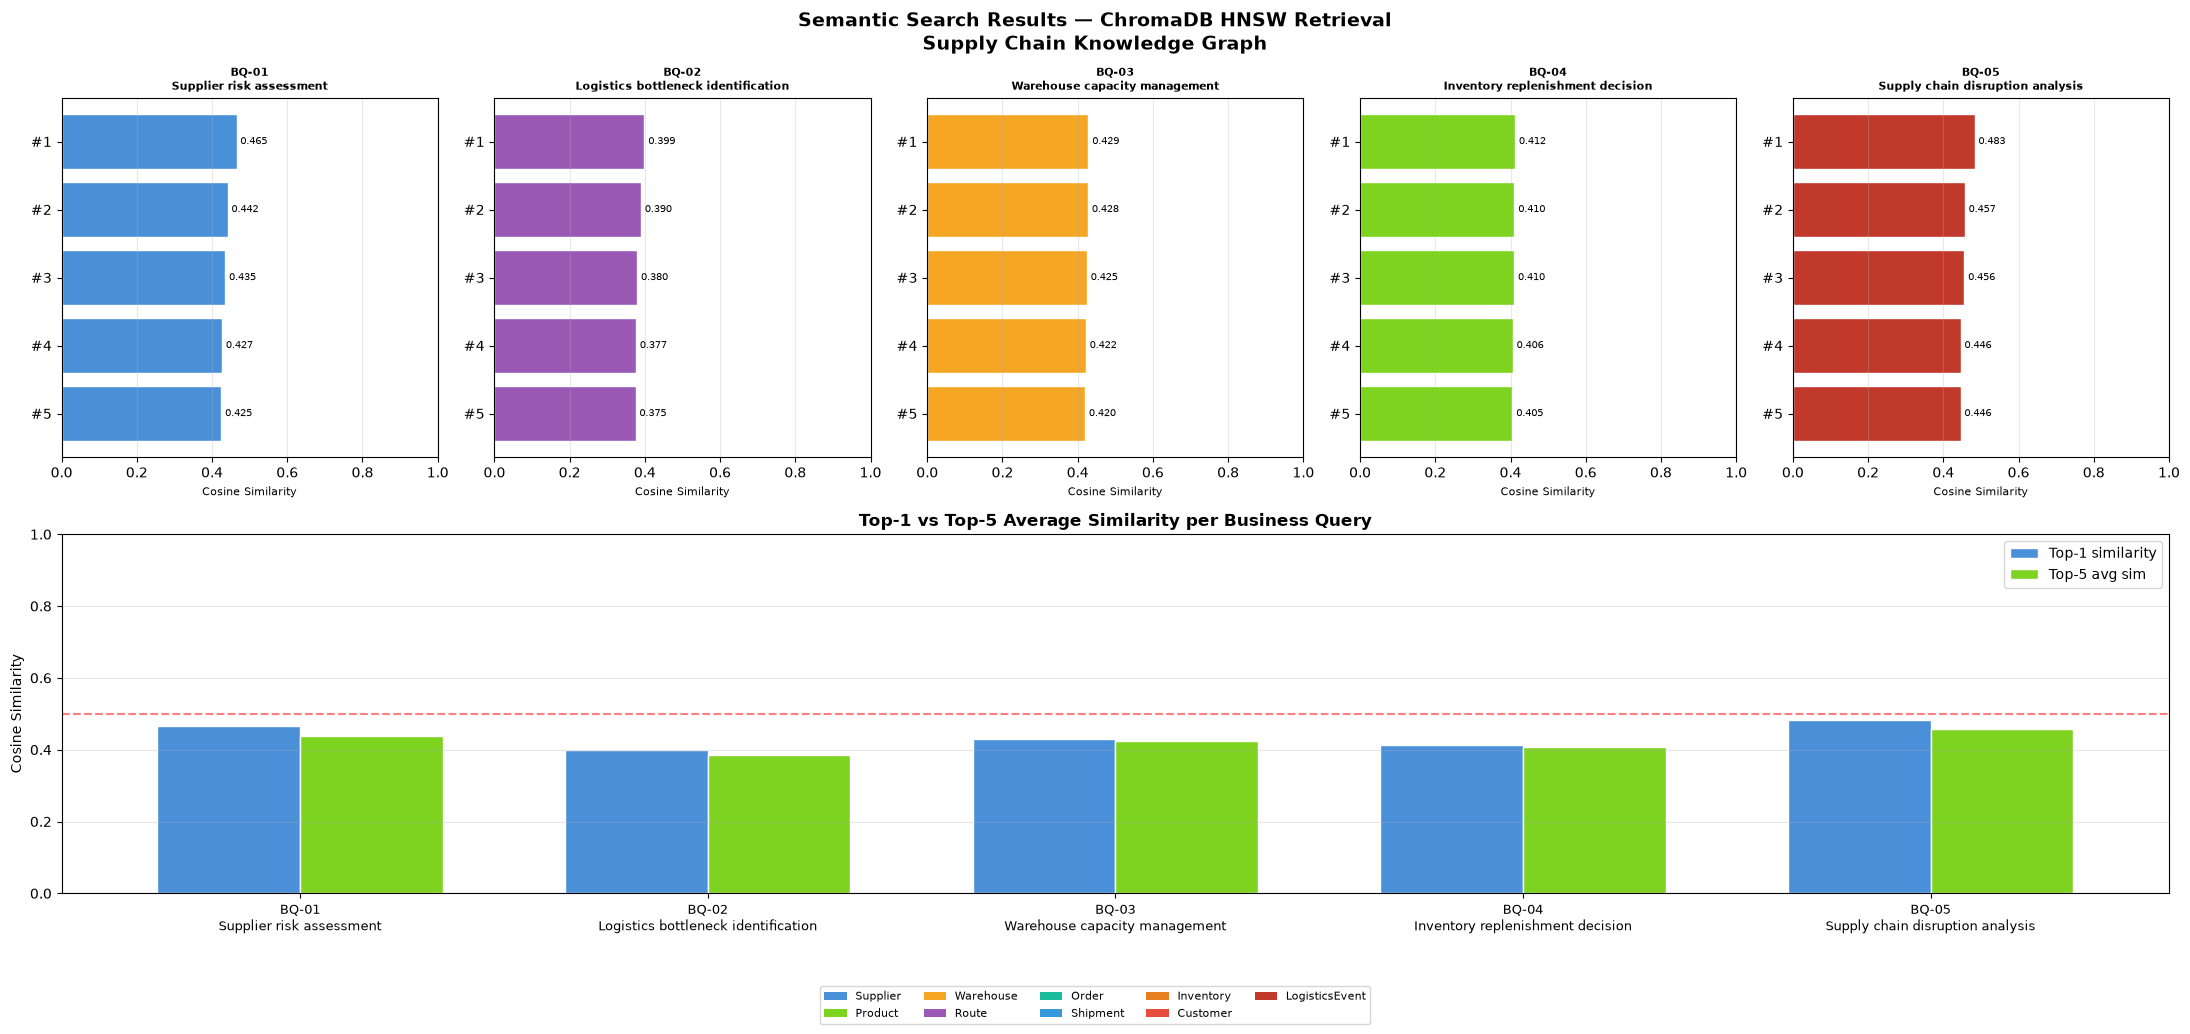

Results chart saved → outputs/3b_semantic_search_results.png


In [68]:
# ── Visualise similarity scores for all 5 queries ─────────────────────────
fig = plt.figure(figsize=(22, 10))
fig.suptitle("Semantic Search Results — ChromaDB HNSW Retrieval\n"
             "Supply Chain Knowledge Graph", fontsize=14, fontweight="bold")

# Top row: per-query similarity bar charts
for col, bq in enumerate(BUSINESS_QUERIES):
    ax  = fig.add_subplot(2, 5, col + 1)
    df_res = all_results[bq["id"]]
    colors = [ENTITY_COLORS.get(e, "#95A5A6") for e in df_res["entity_type"]]

    bars = ax.barh(
        [f"#{r}" for r in df_res["rank"]],
        df_res["similarity"],
        color=colors, edgecolor="white",
    )
    ax.set_xlim(0, 1)
    ax.set_title(f"{bq['id']}\n{bq['business_use']}", fontsize=8, fontweight="bold")
    ax.set_xlabel("Cosine Similarity", fontsize=8)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    for bar, sim in zip(bars, df_res["similarity"]):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{sim:.3f}", va="center", fontsize=7)

# Bottom row: top-1 vs top-5 avg across queries
ax_bot = fig.add_subplot(2, 1, 2)
x  = np.arange(len(BUSINESS_QUERIES))
w  = 0.35
ax_bot.bar(x - w/2, df_summary["Top-1 Sim"],    w,
           label="Top-1 similarity", color="#4A90D9", edgecolor="white")
ax_bot.bar(x + w/2, df_summary["Top-5 Avg Sim"], w,
           label="Top-5 avg sim",    color="#7ED321", edgecolor="white")
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(
    [f"{bq['id']}\n{bq['business_use']}" for bq in BUSINESS_QUERIES],
    fontsize=9
)
ax_bot.set_ylim(0, 1)
ax_bot.set_ylabel("Cosine Similarity")
ax_bot.set_title("Top-1 vs Top-5 Average Similarity per Business Query",
                 fontweight="bold")
ax_bot.legend()
ax_bot.grid(axis="y", alpha=0.3)
ax_bot.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="0.5 threshold")

# Shared entity-type legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, fc=ENTITY_COLORS.get(e, "#95A5A6"), label=e)
    for e in ENTITY_COLORS if e != "Other"
]
fig.legend(handles=legend_patches, loc="lower center", ncol=5,
           fontsize=8, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUT_DIR / "3b_semantic_search_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Results chart saved → outputs/3b_semantic_search_results.png")



In [69]:
# ──────── Sample Context Builder: Show how retrieved chunks will be assembled into RAG context ───────────
# In RAG phase, this context string is passed to the Groq LLM as background knowledge.
# ─────────────────────────────────────────────────────────────────────────────────────────────────────────

def build_rag_context(
    query     : str,
    n_results : int = 5,
    filter_type: Optional[str] = None,
) -> str:
    """
    Retrieve top-n chunks and format them as a numbered context block
    ready to be injected into an LLM prompt.
    """
    df_res = semantic_search(query, n_results=n_results,
                             filter_type=filter_type, verbose=False)
    lines = [
        f"Supply Chain Knowledge Base — Context for: \n'{query}'",
        "=" * 60,
    ]
    for _, row in df_res.iterrows():
        lines.append(
            f"[{row['rank']}] [{row['entity_type']}] (similarity={row['similarity']:.3f})"
        )
        lines.append(f"    {row['chunk']}")
        lines.append("")
    return "\n".join(lines)

# Demo: show context for BQ-01
demo_query   = BUSINESS_QUERIES[0]["query"]
demo_context = build_rag_context(demo_query, n_results=5)

print("Sample RAG Context Block (will be passed to LLM in RAG Phase):")
print("─" * 68)
print(demo_context)
print("─" * 68)
print(f"\nContext builder ready for RAG phase.")

Sample RAG Context Block (will be passed to LLM in RAG Phase):
────────────────────────────────────────────────────────────────────
Supply Chain Knowledge Base — Context for: 
'Which suppliers have a lead time over 20 days and low reliability?'
[1] [Supplier] (similarity=0.465)
    14 has supplier 5.

[2] [Supplier] (similarity=0.442)
    18 has supplier 5.

[3] [Supplier] (similarity=0.435)
    14 has supplier 6.

[4] [Supplier] (similarity=0.427)
    20 has supplier 4.

[5] [Supplier] (similarity=0.425)
    8 has supplier 5.

────────────────────────────────────────────────────────────────────

Context builder ready for RAG phase.


### Section G — Phase 2 Complete: Artifact Checklist

In [70]:

# ── completion summary ────────────────────────────────────────────
print("=" * 65)
print("  Completion Summary ")
print("  Embeddings · Fine-Tuning · ChromaDB · Semantic Search")
print("=" * 65)

avg_top1 = df_summary["Top-1 Sim"].mean()
avg_top5 = df_summary["Top-5 Avg Sim"].mean()

print("\nRETRIEVAL PERFORMANCE")
print(f"   Business queries run   : {len(BUSINESS_QUERIES)}")
print(f"   Avg top-1 similarity   : {avg_top1:.4f}")
print(f"   Avg top-5 avg sim      : {avg_top5:.4f}")

print("\nCHROMADB INDEX")
print(f"   Collection name        : {COLLECTION_NAME}")
print(f"   Total documents        : {collection.count()}")
print(f"   Distance metric        : cosine  (HNSW)")
print(f"   Embedding dimension    : {ft_model.get_sentence_embedding_dimension()}")

print("\n ARTIFACTS")
artefacts = [
    ("Notebook 02_01", "outputs/3a_chunk_distribution.png", "Corpus analysis"),
    ("Notebook 02_01", "outputs/3a_base_pca.png",           "Base embeddings PCA"),
    ("Notebook 02_01", "outputs/3a_comparison.png",          "Base vs FT comparison"),
    ("Notebook 02_01", "outputs/3a_pca_comparison.png",      "PCA before/after"),
    ("Notebook 02_01", "models/fine_tuned_embedder/",        "Fine-tuned model"),
    ("Notebook 02_01", "outputs/ft_embeddings.npy",          "FT embeddings array"),
    ("Notebook 02_01", "outputs/chunk_metadata.json",        "Chunk metadata"),
    ("Notebook 02_02", "outputs/3b_index_distribution.png",  "Index distribution"),
    ("Notebook 02_02", "outputs/3b_semantic_search_results.png","Search results chart"),
]
for origin, path, desc in artefacts:
    print(f"  [{origin}]  {path:<40} — {desc}")

print("=" * 65)

  Completion Summary 
  Embeddings · Fine-Tuning · ChromaDB · Semantic Search

RETRIEVAL PERFORMANCE
   Business queries run   : 5
   Avg top-1 similarity   : 0.4376
   Avg top-5 avg sim      : 0.4227

CHROMADB INDEX
   Collection name        : supply_chain_kg
   Total documents        : 1410
   Distance metric        : cosine  (HNSW)
   Embedding dimension    : 384

 ARTIFACTS
  [Notebook 02_01]  outputs/3a_chunk_distribution.png        — Corpus analysis
  [Notebook 02_01]  outputs/3a_base_pca.png                  — Base embeddings PCA
  [Notebook 02_01]  outputs/3a_comparison.png                — Base vs FT comparison
  [Notebook 02_01]  outputs/3a_pca_comparison.png            — PCA before/after
  [Notebook 02_01]  models/fine_tuned_embedder/              — Fine-tuned model
  [Notebook 02_01]  outputs/ft_embeddings.npy                — FT embeddings array
  [Notebook 02_01]  outputs/chunk_metadata.json              — Chunk metadata
  [Notebook 02_02]  outputs/3b_index_distribution.p